# LIDC-IDRI Preprocessing Master Notebook

## 1. Mount Google Drive and install packages

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

!pip -q install pylidc pydicom scikit-image scikit-learn scipy pandas tqdm pyyaml pillow
print('Environment setup complete.')


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 63.0 MB/s eta 0:00:00
Environment setup complete.


## 2. Imports, compatibility fixes, and reproducibility

In [2]:
import os, re, json, math, random, shutil, zipfile, warnings, traceback, hashlib
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import yaml
import pydicom
import pylidc as pl
from pylidc.utils import consensus
from scipy.ndimage import zoom as ndi_zoom
from skimage.transform import resize
from sklearn.model_selection import StratifiedGroupKFold

# pylidc compatibility with modern NumPy / configparser.
if not hasattr(np, 'int'): np.int = int
if not hasattr(np, 'float'): np.float = float
import configparser
if not hasattr(configparser, 'SafeConfigParser'):
    configparser.SafeConfigParser = configparser.ConfigParser

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('NumPy:', np.__version__)
print('pylidc:', getattr(pl, '__version__', 'unknown'))
print('Seed:', SEED)


/usr/local/lib/python3.13/dist-packages/pylidc/__init__.py:27: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as _pr


NumPy: 2.1.3
pylidc: 0.2.3
Seed: 42


## 3. Project paths — exact requested folder structure

In [3]:
MYDRIVE = Path('/content/drive/MyDrive')
# Keep compatibility with the existing project layout. Change only this root if needed.
THESIS_ROOT = MYDRIVE / 'Thesis_Work/LIDC_Thesis'
LIDC_ROOT = THESIS_ROOT / 'LIDC'

PATHS = {
    'raw': LIDC_ROOT / 'raw',
    'xml_zip': LIDC_ROOT / 'LIDC-XML-only.zip',
    'annotations': LIDC_ROOT / 'annotations',
    'xml': LIDC_ROOT / 'annotations' / 'xml',
    'annotation_inventory': LIDC_ROOT / 'annotations' / 'annotation_inventory.csv',
    'preprocessing': LIDC_ROOT / 'preprocessing',
    'notebooks': LIDC_ROOT / 'preprocessing' / 'notebooks',
    'scripts': LIDC_ROOT / 'preprocessing' / 'scripts',
    'logs': LIDC_ROOT / 'preprocessing' / 'logs',
    'configs': LIDC_ROOT / 'preprocessing' / 'configs',
    'processed': LIDC_ROOT / 'processed',
    'patches': LIDC_ROOT / 'processed' / 'patches',
    'masks': LIDC_ROOT / 'processed' / 'masks',
    'metadata': LIDC_ROOT / 'processed' / 'metadata',
    'arrays': LIDC_ROOT / 'processed' / 'arrays',
    'previews': LIDC_ROOT / 'processed' / 'previews',
    'preview_samples': LIDC_ROOT / 'processed' / 'previews' / 'sample_patches',
    'preview_labels': LIDC_ROOT / 'processed' / 'previews' / 'label_examples',
    'preview_qc': LIDC_ROOT / 'processed' / 'previews' / 'quality_control',
}
for path in PATHS.values():
    if path.suffix in {'.zip', '.csv'}: continue
    path.mkdir(parents=True, exist_ok=True)

# Folder names are storage only. Labels are NEVER inferred from them downstream.
for cls in ['benign', 'indeterminate', 'malignant']:
    (PATHS['patches'] / cls).mkdir(parents=True, exist_ok=True)
    (PATHS['masks'] / cls).mkdir(parents=True, exist_ok=True)

print('LIDC root:', LIDC_ROOT)
print('Raw DICOM folder:', PATHS['raw'])
print('XML zip:', PATHS['xml_zip'])


LIDC root: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC
Raw DICOM folder: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/raw
XML zip: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/LIDC-XML-only.zip


## 4. Save preprocessing configuration and class mapping

In [5]:
PILOT_MAX_PATIENTS = None

CONFIG = {
    'preprocessing_version': '3.2-corrected',
    'project': {'name': 'LIDC-IDRI HAAL preprocessing', 'seed': SEED},
    'PILOT_MAX_PATIENTS': PILOT_MAX_PATIENTS,
    'selection': {'minimum_diameter_mm': 3.0, 'minimum_radiologists': 3},
    'labels': {
        'num_classes': 3,
        'primary_rule': 'median <=2 benign; 2.5-3.5 indeterminate; >=4 malignant',
        'half_median_policy': '2.5 and 3.5 are indeterminate',
        'sensitivity_rule': 'median <2.5 benign; 2.5<=median<3.5 indeterminate; >=3.5 malignant',
        'reader_vote_mapping': 'reader score 1-2 benign; 3 indeterminate; 4-5 malignant',
    },
    'variance': {'type': 'population', 'ddof': 0, 'normalizer': 4.0},
    'crop_geometry': {
        'source': 'largest consensus-contour axial slice',
        'target_spacing_mm': 1.0,
        'field_of_view_mm': 64.0,
        'output_size_px': 224,
        'hu_low': -1000.0,
        'hu_high': 400.0,
        'consensus_level': 0.5,
        'consensus_pad': 30,
    },
    'cross_validation': {'folds': 5, 'method': 'StratifiedGroupKFold', 'seed': SEED},
    'training_augmentation_not_applied_during_preprocessing': {
        'horizontal_flip': True, 'vertical_flip': True,
        'rotation_degrees': 15, 'translation_fraction': 0.10,
        'elastic_deformation': False, 'intensity_jitter': False,
    },
}
CLASS_MAPPING = {'benign': 0, 'indeterminate': 1, 'malignant': 2}

with open(PATHS['configs'] / 'preprocessing_config.yaml', 'w') as f:
    yaml.safe_dump(CONFIG, f, sort_keys=False)
with open(PATHS['configs'] / 'class_mapping.json', 'w') as f:
    json.dump(CLASS_MAPPING, f, indent=2)

shared_run_config = {
    'preprocessing_version': CONFIG['preprocessing_version'],
    'PILOT_MAX_PATIENTS': PILOT_MAX_PATIENTS,
    'seed': SEED,
    'crop_geometry': CONFIG['crop_geometry'],
    'label_policy': CONFIG['labels'],
    'fold_policy': CONFIG['cross_validation'],
}
for name in ['shared_pipeline_config.json', 'preprocessing_run_config.json']:
    (PATHS['metadata'] / name).write_text(json.dumps(shared_run_config, indent=2))

print(yaml.safe_dump(CONFIG, sort_keys=False))


preprocessing_version: 3.2-corrected
project:
  name: LIDC-IDRI HAAL preprocessing
  seed: 42
PILOT_MAX_PATIENTS: null
selection:
  minimum_diameter_mm: 3.0
  minimum_radiologists: 3
labels:
  num_classes: 3
  primary_rule: median <=2 benign; 2.5-3.5 indeterminate; >=4 malignant
  half_median_policy: 2.5 and 3.5 are indeterminate
  sensitivity_rule: median <2.5 benign; 2.5<=median<3.5 indeterminate; >=3.5 malignant
  reader_vote_mapping: reader score 1-2 benign; 3 indeterminate; 4-5 malignant
variance:
  type: population
  ddof: 0
  normalizer: 4.0
crop_geometry:
  source: largest consensus-contour axial slice
  target_spacing_mm: 1.0
  field_of_view_mm: 64.0
  output_size_px: 224
  hu_low: -1000.0
  hu_high: 400.0
  consensus_level: 0.5
  consensus_pad: 30
cross_validation:
  folds: 5
  method: StratifiedGroupKFold
  seed: 42
training_augmentation_not_applied_during_preprocessing:
  horizontal_flip: true
  vertical_flip: true
  rotation_degrees: 15
  translation_fraction: 0.1
  elasti

## 5. Logging helpers

In [6]:
PREPROCESSING_LOG = PATHS['logs'] / 'preprocessing_log.csv'
FAILED_PATIENTS_LOG = PATHS['logs'] / 'failed_patients.csv'
EXCLUDED_NODULES_LOG = PATHS['logs'] / 'excluded_nodules.csv'

log_rows, failed_patient_rows, excluded_rows = [], [], []

def log_event(stage, status, message='', patient_id='', nodule_id=''):
    log_rows.append({
        'timestamp': datetime.now().isoformat(timespec='seconds'),
        'stage': stage, 'status': status, 'patient_id': patient_id,
        'nodule_id': nodule_id, 'message': str(message)
    })

def flush_logs():
    pd.DataFrame(log_rows).to_csv(PREPROCESSING_LOG, index=False)
    pd.DataFrame(failed_patient_rows, columns=['patient_id','stage','error']).to_csv(FAILED_PATIENTS_LOG, index=False)
    pd.DataFrame(excluded_rows, columns=['patient_id','nodule_id','reason','details']).to_csv(EXCLUDED_NODULES_LOG, index=False)

log_event('setup', 'OK', 'Folders and configs initialized')
flush_logs()

## 6. Scan raw DICOM tree and build patient inventory

In [7]:
def scan_raw_dicom_tree(raw_root):
    rows = []
    all_files = [p for p in Path(raw_root).rglob('*') if p.is_file()]
    print(f'Files found under raw/: {len(all_files):,}')

    for fp in tqdm(all_files, desc='Inspecting DICOM headers'):
        try:
            ds = pydicom.dcmread(str(fp), stop_before_pixels=True, force=True)
            if not hasattr(ds, 'SeriesInstanceUID') or not hasattr(ds, 'SOPInstanceUID'):
                continue
            patient_id = str(getattr(ds, 'PatientID', '') or '').strip() or fp.parent.name
            rows.append({
                'patient_id': patient_id,
                'study_instance_uid': str(getattr(ds, 'StudyInstanceUID', '')),
                'series_instance_uid': str(getattr(ds, 'SeriesInstanceUID', '')),
                'sop_instance_uid': str(getattr(ds, 'SOPInstanceUID', '')),
                'modality': str(getattr(ds, 'Modality', '')),
                'rows': int(getattr(ds, 'Rows', 0) or 0),
                'columns': int(getattr(ds, 'Columns', 0) or 0),
                'slice_thickness': float(getattr(ds, 'SliceThickness', np.nan) or np.nan),
                'pixel_spacing': '\\'.join(map(str, getattr(ds, 'PixelSpacing', []))),
                'file_path': str(fp),
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

dicom_inventory = scan_raw_dicom_tree(PATHS['raw'])
if dicom_inventory.empty:
    raise FileNotFoundError(f'No readable DICOM files found under {PATHS["raw"]}')

patient_ids_local = sorted(dicom_inventory['patient_id'].dropna().unique().tolist())
patient_inventory = dicom_inventory.groupby('patient_id').agg(
    dicom_files=('sop_instance_uid','count'),
    studies=('study_instance_uid','nunique'),
    series=('series_instance_uid','nunique'),
    min_rows=('rows','min'), max_rows=('rows','max'),
    min_columns=('columns','min'), max_columns=('columns','max')
).reset_index()

patient_inventory.to_csv(PATHS['metadata'] / 'patient_inventory.csv', index=False)
dicom_inventory.to_csv(PATHS['metadata'] / 'dicom_inventory.csv', index=False)
print('Local patients detected:', len(patient_ids_local))
display(patient_inventory.head(30))
log_event('raw_data_check','OK',f'Detected {len(patient_ids_local)} local patients')
flush_logs()

Files found under raw/: 5,923


Inspecting DICOM headers:   0%|          | 0/5923 [00:00<?, ?it/s]

Local patients detected: 30


,patient_id,dicom_files,studies,series,min_rows,max_rows,min_columns,max_columns
0,LIDC-IDRI-0001,143,2,10,0,2022,0,2022
1,LIDC-IDRI-0002,266,2,6,0,2007,0,1721
2,LIDC-IDRI-0003,171,2,28,0,2022,0,2022
3,LIDC-IDRI-0004,250,2,10,0,2269,0,2265
4,LIDC-IDRI-0005,153,2,20,0,2022,0,1736
5,LIDC-IDRI-0006,151,2,18,0,2022,0,1736
6,LIDC-IDRI-0007,159,2,12,0,2022,0,2022
7,LIDC-IDRI-0008,149,2,16,0,2022,0,2022
8,LIDC-IDRI-0009,261,2,6,0,2001,0,1831
9,LIDC-IDRI-0010,292,2,16,0,2845,0,3000


### Patient folder naming note
Your wrapper folders can be named `patient_001`, `patient_002`, etc. The matching step uses the **DICOM header `PatientID`** (normally `LIDC-IDRI-xxxx`) so it can still match pylidc correctly.

## 7. Extract official XML archive

In [8]:
if not PATHS['xml_zip'].exists():
    raise FileNotFoundError(f'Place LIDC-XML-only.zip at {PATHS["xml_zip"]}')

existing_xml = list(PATHS['xml'].rglob('*.xml'))
if not existing_xml:
    print('Extracting XML archive...')
    with zipfile.ZipFile(PATHS['xml_zip'], 'r') as zf:
        zf.extractall(PATHS['xml'])

xml_files = sorted(PATHS['xml'].rglob('*.xml'))
print(f'XML files available: {len(xml_files):,}')
log_event('xml_extraction','OK',f'{len(xml_files)} XML files available')
flush_logs()

XML files available: 1,319


## 8. Build XML annotation inventory

In [9]:
import xml.etree.ElementTree as ET

def local_tag(tag):
    return tag.split('}',1)[-1] if '}' in tag else tag

def parse_xml_summary(xml_path):
    result = {
        'xml_path': str(xml_path), 'series_instance_uid': '', 'study_instance_uid': '',
        'reading_sessions': 0, 'malignancy_entries': 0, 'malignancy_scores': '',
        'parse_status': 'OK', 'parse_error': ''
    }
    try:
        root = ET.parse(xml_path).getroot()
        scores = []
        for elem in root.iter():
            tag = local_tag(elem.tag)
            txt = (elem.text or '').strip()
            if tag == 'SeriesInstanceUid' and not result['series_instance_uid']:
                result['series_instance_uid'] = txt
            elif tag == 'StudyInstanceUID' and not result['study_instance_uid']:
                result['study_instance_uid'] = txt
            elif tag == 'readingSession':
                result['reading_sessions'] += 1
            elif tag == 'malignancy':
                try: scores.append(int(txt))
                except Exception: pass
        result['malignancy_entries'] = len(scores)
        result['malignancy_scores'] = '|'.join(map(str,scores))
    except Exception as e:
        result['parse_status'] = 'FAILED'
        result['parse_error'] = repr(e)
    return result

xml_inventory = pd.DataFrame([parse_xml_summary(p) for p in tqdm(xml_files, desc='Parsing XML inventory')])
local_series = set(dicom_inventory['series_instance_uid'].astype(str))
xml_inventory['series_downloaded_locally'] = xml_inventory['series_instance_uid'].astype(str).isin(local_series)
xml_inventory.to_csv(PATHS['annotation_inventory'], index=False)
xml_inventory.to_csv(PATHS['metadata'] / 'annotation_inventory.csv', index=False)
print('XML entries matching downloaded series:', int(xml_inventory['series_downloaded_locally'].sum()))
display(xml_inventory.head(30))

Parsing XML inventory:   0%|          | 0/1319 [00:00<?, ?it/s]

XML entries matching downloaded series: 30


,xml_path,series_instance_uid,study_instance_uid,reading_sessions,malignancy_entries,malignancy_scores,parse_status,parse_error,series_downloaded_locally
0,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.340202188094...,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,4,2,1|3,OK,,False
1,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,1.3.6.1.4.1.14519.5.2.1.6279.6001.339170810277...,4,13,3|3|4|5|4|4|5|1|5|5|3|3|3,OK,,False
2,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303241414168...,4,9,5|2|5|3|2|4|3|2|3,OK,,False
3,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.213233719488...,1.3.6.1.4.1.14519.5.2.1.6279.6001.303921580531...,4,4,3|3|1|3,OK,,False
4,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.340202188094...,1.3.6.1.4.1.14519.5.2.1.6279.6001.584233139051...,4,3,4|1|3,OK,,False
5,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.311102747717...,1.3.6.1.4.1.14519.5.2.1.6279.6001.924939006160...,4,6,2|3|3|4|3|3,OK,,False
6,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.166112018536...,1.3.6.1.4.1.14519.5.2.1.6279.6001.140071422310...,4,4,3|5|3|3,OK,,False
7,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.151647338241...,1.3.6.1.4.1.14519.5.2.1.6279.6001.218658642102...,4,12,4|2|1|1|3|4|5|3|3|3|3|3,OK,,False
8,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.207201727479...,1.3.6.1.4.1.14519.5.2.1.6279.6001.338445093314...,4,21,1|2|1|2|1|1|1|1|1|3|3|3|3|3|3|4|3|2|2|3|3,OK,,False
9,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,1.3.6.1.4.1.14519.5.2.1.6279.6001.400871509992...,1.3.6.1.4.1.14519.5.2.1.6279.6001.249778071616...,4,4,1|1|3|4,OK,,False


## 9. Configure pylidc and match local scan records

In [10]:
pylidcrc = Path.home() / '.pylidcrc'
pylidcrc.write_text(f'[dicom]\npath = {PATHS["raw"]}\nwarn = True\n')
(PATHS['configs'] / '.pylidcrc').write_text(pylidcrc.read_text())
print(pylidcrc.read_text())

all_local_scans = pl.query(pl.Scan).filter(pl.Scan.patient_id.in_(patient_ids_local)).all()
print('Matched pylidc scan rows:', len(all_local_scans))

scan_df = pd.DataFrame([{
    'scan_db_id': s.id,
    'patient_id': s.patient_id,
    'study_instance_uid': s.study_instance_uid,
    'series_instance_uid': s.series_instance_uid,
    'slice_thickness': s.slice_thickness,
    'pixel_spacing': s.pixel_spacing,
} for s in all_local_scans])
scan_df.to_csv(PATHS['metadata'] / 'pylidc_scan_inventory.csv', index=False)

matched = set(scan_df['patient_id']) if not scan_df.empty else set()
for pid in patient_ids_local:
    if pid not in matched:
        failed_patient_rows.append({'patient_id':pid,'stage':'pylidc_match','error':'No pylidc Scan matched this PatientID'})
flush_logs()
display(scan_df.head(30))

[dicom]
path = /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/raw
warn = True

Matched pylidc scan rows: 30


,scan_db_id,patient_id,study_instance_uid,series_instance_uid,slice_thickness,pixel_spacing
0,12,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,2.50,0.703125
1,13,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,1.25,0.681641
2,14,LIDC-IDRI-0003,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,2.50,0.820312
3,15,LIDC-IDRI-0004,1.3.6.1.4.1.14519.5.2.1.6279.6001.191425307197...,1.3.6.1.4.1.14519.5.2.1.6279.6001.323541312620...,1.25,0.822266
4,16,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,2.50,0.664062
5,17,LIDC-IDRI-0006,1.3.6.1.4.1.14519.5.2.1.6279.6001.324680252006...,1.3.6.1.4.1.14519.5.2.1.6279.6001.132817748896...,2.50,0.625000
6,18,LIDC-IDRI-0007,1.3.6.1.4.1.14519.5.2.1.6279.6001.280315210397...,1.3.6.1.4.1.14519.5.2.1.6279.6001.272348349298...,2.50,0.781250
7,19,LIDC-IDRI-0008,1.3.6.1.4.1.14519.5.2.1.6279.6001.185810436275...,1.3.6.1.4.1.14519.5.2.1.6279.6001.774060103415...,2.50,0.781250
8,20,LIDC-IDRI-0009,1.3.6.1.4.1.14519.5.2.1.6279.6001.225213110794...,1.3.6.1.4.1.14519.5.2.1.6279.6001.286061375572...,1.25,0.781250
9,21,LIDC-IDRI-0010,1.3.6.1.4.1.14519.5.2.1.6279.6001.303099231937...,1.3.6.1.4.1.14519.5.2.1.6279.6001.416701701108...,1.25,0.878906


## 10. Validate DICOM pixel access

In [11]:
VALID_SCANS, scan_validation_rows = [], []
for scan in tqdm(all_local_scans, desc='Validating scan pixel access'):
    try:
        vol = scan.to_volume()
        VALID_SCANS.append(scan)
        scan_validation_rows.append({
            'patient_id':scan.patient_id, 'scan_db_id':scan.id,
            'series_instance_uid':scan.series_instance_uid, 'status':'OK',
            'volume_shape':'x'.join(map(str,vol.shape)),
            'min_hu':float(np.nanmin(vol)), 'max_hu':float(np.nanmax(vol)), 'error':''
        })
    except Exception as e:
        failed_patient_rows.append({'patient_id':scan.patient_id,'stage':'scan.to_volume','error':repr(e)})
        scan_validation_rows.append({
            'patient_id':scan.patient_id,'scan_db_id':scan.id,
            'series_instance_uid':scan.series_instance_uid,'status':'FAILED',
            'volume_shape':'','min_hu':np.nan,'max_hu':np.nan,'error':repr(e)
        })

scan_validation_df = pd.DataFrame(scan_validation_rows)
print(scan_validation_df)
scan_validation_df.to_csv(PATHS['metadata'] / 'scan_pixel_validation.csv', index=False)
print(f'Valid scans: {len(VALID_SCANS)} / {len(all_local_scans)}')
flush_logs()
if len(VALID_SCANS) == 0:
    raise RuntimeError('No scan volume could be loaded. Inspect scan_pixel_validation.csv and raw folder placement.')

Validating scan pixel access:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a 

## 11. Cluster annotations; compute authoritative labels, reader-vote targets, and legacy variance target


In [12]:
MIN_DIAMETER_MM = float(CONFIG['selection']['minimum_diameter_mm'])
MIN_RADIOLOGISTS = int(CONFIG['selection']['minimum_radiologists'])
VARIANCE_NORMALIZER = float(CONFIG['variance']['normalizer'])
LN3 = float(np.log(3.0))

def label_from_median(median_score):
    """Primary hard-label policy. Explicitly resolves half-medians."""
    m = float(median_score)
    if m <= 2.0: return 'benign', 0
    if m <= 3.5: return 'indeterminate', 1   # includes 2.5 and 3.5
    return 'malignant', 2

def sensitivity_label_from_median(median_score):
    """Second defensible rule for the required hard-label sensitivity analysis."""
    m = float(median_score)
    if m < 2.5: return 'benign', 0
    if m < 3.5: return 'indeterminate', 1
    return 'malignant', 2                   # 3.5 changes under this rule

def reader_score_to_class(score):
    s = float(score)
    if s <= 2: return 0
    if s == 3: return 1
    if s >= 4: return 2
    raise ValueError(f'Unexpected malignancy score: {score}')

def reader_vote_distribution(scores):
    classes = np.array([reader_score_to_class(s) for s in scores], dtype=int)
    counts = np.bincount(classes, minlength=3).astype(np.float64)
    q = counts / counts.sum()
    nz = q > 0
    h = float(-(q[nz] * np.log(q[nz])).sum() / LN3)
    return q, h

raw_nodule_rows = []
scan_cluster_cache = {}
for scan in tqdm(VALID_SCANS, desc='Clustering nodule annotations'):
    try:
        clusters = scan.cluster_annotations()
        scan_cluster_cache[scan.id] = clusters
        for cluster_idx, anns in enumerate(clusters):
            if not anns: continue
            scores = np.array([float(a.malignancy) for a in anns], dtype=float)
            ni = len(scores)
            median_score = float(np.median(scores))
            var_raw = float(np.var(scores, ddof=0))
            V = float(np.clip(var_raw / VARIANCE_NORMALIZER, 0.0, 1.0))
            label_name, label_id = label_from_median(median_score)
            sens_name, sens_id = sensitivity_label_from_median(median_score)
            q, q_entropy = reader_vote_distribution(scores)
            diameter_mm = float(np.mean([float(a.diameter) for a in anns]))
            centroid = np.mean(np.array([a.centroid for a in anns], dtype=float), axis=0)
            nid = f'{scan.patient_id}_S{scan.id}_N{cluster_idx:03d}'
            raw_nodule_rows.append({
                'nodule_id': nid, 'patient_id': scan.patient_id, 'scan_db_id': scan.id,
                'study_instance_uid': scan.study_instance_uid, 'series_instance_uid': scan.series_instance_uid,
                'cluster_index': cluster_idx, 'n_radiologists': ni,
                'malignancy_scores': '|'.join(str(int(x)) for x in scores),
                'malignancy_mean': float(scores.mean()), 'malignancy_median': median_score,
                'diameter_mm': diameter_mm, 'variance_raw': var_raw, 'variance_normalized': V,
                # Legacy scalar-HAAL mask only. Classification/soft-target learning keeps every sample.
                'alignment_mask': int(V > 0),
                'label_name': label_name, 'label_id': label_id,
                'label_name_sensitivity': sens_name, 'label_id_sensitivity': sens_id,
                'q_benign': float(q[0]), 'q_indeterminate': float(q[1]), 'q_malignant': float(q[2]),
                'reader_vote_entropy_normalized': q_entropy,
                'centroid_i': float(centroid[0]), 'centroid_j': float(centroid[1]), 'centroid_k': float(centroid[2]),
            })
    except Exception as e:
        failed_patient_rows.append({'patient_id':scan.patient_id,'stage':'cluster_annotations','error':repr(e)})

nodule_raw_df = pd.DataFrame(raw_nodule_rows)
if nodule_raw_df.empty:
    raise RuntimeError('No clustered nodules were produced.')
nodule_raw_df.to_csv(PATHS['metadata'] / 'detailed_nodule_metadata_raw.csv', index=False)
print('Raw clustered nodules:', len(nodule_raw_df))
display(nodule_raw_df.head())
print(nodule_raw_df.to_string())
print('Primary half-median counts:')
display(nodule_raw_df[nodule_raw_df['malignancy_median'].isin([2.5,3.5,4.5])][['malignancy_median','label_name','label_name_sensitivity']].value_counts().to_frame('n'))
flush_logs()


Clustering nodule annotations:   0%|          | 0/30 [00:00<?, ?it/s]

Raw clustered nodules: 86


,nodule_id,patient_id,scan_db_id,study_instance_uid,series_instance_uid,cluster_index,n_radiologists,malignancy_scores,malignancy_mean,malignancy_median,...,label_id,label_name_sensitivity,label_id_sensitivity,q_benign,q_indeterminate,q_malignant,reader_vote_entropy_normalized,centroid_i,centroid_j,centroid_k
0,LIDC-IDRI-0001_S12_N000,LIDC-IDRI-0001,12,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,0,4,5|5|5|4,4.75,5.0,...,2,malignant,2,0.00,0.00,1.00,-0.000000,366.795831,315.981774,89.655133
1,LIDC-IDRI-0002_S13_N000,LIDC-IDRI-0002,13,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,0,2,5|4,4.50,4.5,...,2,malignant,2,0.00,0.00,1.00,-0.000000,361.162287,345.222282,185.044542
2,LIDC-IDRI-0003_S14_N000,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,0,1,2,2.00,2.0,...,0,benign,0,1.00,0.00,0.00,-0.000000,346.394690,368.923894,66.148673
3,LIDC-IDRI-0003_S14_N001,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,1,4,5|5|3|4,4.25,4.5,...,2,malignant,2,0.00,0.25,0.75,0.511860,350.255185,366.703876,75.142580
4,LIDC-IDRI-0003_S14_N002,LIDC-IDRI-0003,14,1.3.6.1.4.1.14519.5.2.1.6279.6001.101370605276...,1.3.6.1.4.1.14519.5.2.1.6279.6001.170706757615...,2,4,4|4|3|2,3.25,3.5,...,1,malignant,2,0.25,0.25,0.50,0.946395,197.916860,307.828990,82.595659


                  nodule_id      patient_id  scan_db_id                                                study_instance_uid                                               series_instance_uid  cluster_index  n_radiologists malignancy_scores  malignancy_mean  malignancy_median  diameter_mm  variance_raw  variance_normalized  alignment_mask     label_name  label_id label_name_sensitivity  label_id_sensitivity  q_benign  q_indeterminate  q_malignant  reader_vote_entropy_normalized  centroid_i  centroid_j  centroid_k
0   LIDC-IDRI-0001_S12_N000  LIDC-IDRI-0001          12  1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192              0               4           5|5|5|4         4.750000                5.0    32.755812      0.187500             0.046875               1      malignant         2              malignant                     2  0.000000         0.000000         1.00                       -0.000000  366.7

,,,n
malignancy_median,label_name,label_name_sensitivity,
3.5,indeterminate,malignant,9
2.5,indeterminate,indeterminate,8
4.5,malignant,malignant,4


## 12. Apply inclusion/exclusion rules

In [13]:
keep = (nodule_raw_df['diameter_mm'] >= MIN_DIAMETER_MM) & (nodule_raw_df['n_radiologists'] >= MIN_RADIOLOGISTS)
for _, r in nodule_raw_df.loc[~keep].iterrows():
    reasons=[]
    if r['diameter_mm'] < MIN_DIAMETER_MM: reasons.append('diameter_lt_3mm')
    if r['n_radiologists'] < MIN_RADIOLOGISTS: reasons.append('radiologists_lt_3')
    excluded_rows.append({'patient_id':r['patient_id'],'nodule_id':r['nodule_id'],'reason':'|'.join(reasons),
                          'details':f'diameter_mm={r["diameter_mm"]:.3f}; n_radiologists={int(r["n_radiologists"])}'})

nodule_df = nodule_raw_df.loc[keep].copy().reset_index(drop=True)

# B10/V8: a single pilot switch. Selection is deterministic and preprocessing owns it.
# The downstream notebooks do not independently truncate patients.
all_eligible_patients = sorted(nodule_df['patient_id'].astype(str).unique())
if PILOT_MAX_PATIENTS is not None:
    if int(PILOT_MAX_PATIENTS) < 5:
        raise ValueError('PILOT_MAX_PATIENTS must be >=5 for a 5-fold code path.')
    selected_patients = set(all_eligible_patients[:int(PILOT_MAX_PATIENTS)])
    nodule_df = nodule_df[nodule_df['patient_id'].astype(str).isin(selected_patients)].copy().reset_index(drop=True)
    nodule_df['pilot_included'] = True
else:
    nodule_df['pilot_included'] = True

if nodule_df.empty:
    raise RuntimeError('No eligible nodules remain after filtering/pilot selection.')
print('Before filtering:', len(nodule_raw_df))
print('After filtering/effective cohort:', len(nodule_df))
print('Effective patients:', nodule_df.patient_id.nunique())
print(nodule_df['label_name'].value_counts())
print('Zero-variance retained for classification:', int((nodule_df['variance_normalized']==0).sum()))
print(nodule_df.to_string())
flush_logs()


Before filtering: 86
After filtering/effective cohort: 48
Effective patients: 21
label_name
indeterminate    33
malignant        10
benign            5
Name: count, dtype: int64
Zero-variance retained for classification: 0
                  nodule_id      patient_id  scan_db_id                                                study_instance_uid                                               series_instance_uid  cluster_index  n_radiologists malignancy_scores  malignancy_mean  malignancy_median  diameter_mm  variance_raw  variance_normalized  alignment_mask     label_name  label_id label_name_sensitivity  label_id_sensitivity  q_benign  q_indeterminate  q_malignant  reader_vote_entropy_normalized  centroid_i  centroid_j  centroid_k  pilot_included
0   LIDC-IDRI-0001_S12_N000  LIDC-IDRI-0001          12  1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178  1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192              0               4           5|5|5|4         4

## 13. Physical-geometry patch-generation helpers


In [14]:
OUTPUT_SIZE = int(CONFIG['crop_geometry']['output_size_px'])
TARGET_SPACING_MM = float(CONFIG['crop_geometry']['target_spacing_mm'])
FOV_MM = float(CONFIG['crop_geometry']['field_of_view_mm'])
FOV_PIXELS_1MM = int(round(FOV_MM / TARGET_SPACING_MM))
HU_LOW = float(CONFIG['crop_geometry']['hu_low'])
HU_HIGH = float(CONFIG['crop_geometry']['hu_high'])
CONSENSUS_LEVEL = float(CONFIG['crop_geometry']['consensus_level'])
CONSENSUS_PAD = int(CONFIG['crop_geometry']['consensus_pad'])

def get_central_slice_from_consensus(anns):
    cmask, cbbox, _ = consensus(anns, clevel=CONSENSUS_LEVEL, pad=CONSENSUS_PAD)
    if cmask.ndim != 3 or cmask.shape[2] == 0: raise ValueError('Consensus mask empty/malformed')
    areas = cmask.sum(axis=(0,1))
    if np.max(areas) <= 0: raise ValueError('Consensus mask has no positive pixels')
    k_local = int(np.argmax(areas)); k_full = int(cbbox[2].start + k_local)
    return k_full, k_local, cbbox, cmask

def consensus_slice_centroid(k_local, cbbox, cmask):
    ii, jj = np.nonzero(cmask[:,:,k_local])
    if len(ii) == 0: raise ValueError('Central consensus slice empty')
    return float(ii.mean()+cbbox[0].start), float(jj.mean()+cbbox[1].start)

def crop_with_padding(image2d, center_i, center_j, size, pad_value):
    center_i, center_j = int(round(center_i)), int(round(center_j)); half=size//2
    i0,j0=center_i-half,center_j-half; i1,j1=i0+size,j0+size
    out=np.full((size,size),pad_value,dtype=np.float32)
    si0,sj0=max(i0,0),max(j0,0); si1,sj1=min(i1,image2d.shape[0]),min(j1,image2d.shape[1])
    if si1<=si0 or sj1<=sj0: raise ValueError('Crop does not overlap image')
    di0,dj0=si0-i0,sj0-j0
    out[di0:di0+(si1-si0),dj0:dj0+(sj1-sj0)] = image2d[si0:si1,sj0:sj1]
    return out

def resample_slice_to_target_spacing(image2d, source_spacing_mm, order=1, cval=-1000.0):
    z = float(source_spacing_mm) / TARGET_SPACING_MM
    if not np.isfinite(z) or z <= 0: raise ValueError(f'Invalid pixel spacing {source_spacing_mm}')
    return ndi_zoom(np.asarray(image2d,dtype=np.float32), zoom=(z,z), order=order, mode='constant', cval=cval, prefilter=(order>1)), z

def hu_window_to_unit_interval(patch):
    patch=np.clip(np.asarray(patch,dtype=np.float32),HU_LOW,HU_HIGH)
    return ((patch-HU_LOW)/(HU_HIGH-HU_LOW)).astype(np.float32)

def final_resize(image, order=1):
    return resize(image,(OUTPUT_SIZE,OUTPUT_SIZE),order=order,preserve_range=True,anti_aliasing=(order>0)).astype(np.float32)

def save_preview_png(patch01,path):
    Image.fromarray(np.clip(patch01*255,0,255).astype(np.uint8),mode='L').save(path)


## 14. Generate fixed-physical-FOV 224×224 patches and consensus masks


In [15]:
scan_by_id = {s.id:s for s in VALID_SCANS}
volume_cache = {}
def get_volume(scan):
    if scan.id not in volume_cache:
        volume_cache[scan.id] = scan.to_volume().astype(np.float32)
    return volume_cache[scan.id]

patch_records, patch_arrays, mask_arrays, valid_nodule_rows = [], [], [], []
for _, row in tqdm(nodule_df.iterrows(), total=len(nodule_df), desc='Generating physical-FOV patches'):
    nid, pid = row['nodule_id'], row['patient_id']
    try:
        scan = scan_by_id[int(row['scan_db_id'])]
        clusters = scan_cluster_cache.get(scan.id) or scan.cluster_annotations()
        anns = clusters[int(row['cluster_index'])]
        vol = get_volume(scan); scan_min_hu=float(np.nanmin(vol))
        k_full,k_local,cbbox,cmask = get_central_slice_from_consensus(anns)
        i_center,j_center = consensus_slice_centroid(k_local,cbbox,cmask)
        if not (0 <= k_full < vol.shape[2]): raise IndexError('central slice outside volume')

        source_spacing = float(scan.pixel_spacing)
        slice_1mm, scale = resample_slice_to_target_spacing(vol[:,:,k_full], source_spacing, order=1, cval=scan_min_hu)
        center_i_1mm, center_j_1mm = i_center*scale, j_center*scale
        crop_64 = crop_with_padding(slice_1mm, center_i_1mm, center_j_1mm, FOV_PIXELS_1MM, scan_min_hu)
        patch01 = hu_window_to_unit_interval(final_resize(crop_64, order=1))

        # Consensus mask in full original slice -> same physical transform/crop -> 224 mask.
        mask_full=np.zeros(vol.shape[:2],dtype=np.float32)
        mask_slice=cmask[:,:,k_local].astype(np.float32)
        i0,i1=cbbox[0].start,cbbox[0].stop; j0,j1=cbbox[1].start,cbbox[1].stop
        mask_full[i0:i1,j0:j1]=mask_slice[:i1-i0,:j1-j0]
        mask_1mm,_=resample_slice_to_target_spacing(mask_full,source_spacing,order=0,cval=0.0)
        mask_crop=crop_with_padding(mask_1mm,center_i_1mm,center_j_1mm,FOV_PIXELS_1MM,0.0)
        mask224=(final_resize(mask_crop,order=0)>0.5).astype(np.uint8)

        if patch01.shape!=(224,224) or mask224.shape!=(224,224): raise ValueError('Bad final geometry')
        if not np.isfinite(patch01).all(): raise ValueError('Non-finite patch values')
        if mask224.sum()==0: raise ValueError('Consensus mask vanished after physical resampling')

        class_dir=PATHS['patches']/row['label_name']; mask_dir=PATHS['masks']/row['label_name']
        patch_path=class_dir/f'{nid}.npy'; mask_path=mask_dir/f'{nid}_mask.npy'
        np.save(patch_path,patch01); np.save(mask_path,mask224)
        patch_records.append({
            'nodule_id':nid,'patient_id':pid,'scan_db_id':int(row['scan_db_id']),
            'series_instance_uid':row['series_instance_uid'],'label_id':int(row['label_id']),
            'patch_path':str(patch_path),'consensus_mask_path':str(mask_path),'central_slice_k':int(k_full),
            'crop_center_i_original':float(i_center),'crop_center_j_original':float(j_center),
            'source_pixel_spacing_mm':source_spacing,'target_pixel_spacing_mm':TARGET_SPACING_MM,
            'field_of_view_mm':FOV_MM,'pre_resize_crop_px':FOV_PIXELS_1MM,'output_size_px':OUTPUT_SIZE,
            'scan_min_hu_for_padding':scan_min_hu,'hu_window_low':HU_LOW,'hu_window_high':HU_HIGH,
            'patch_min':float(patch01.min()),'patch_max':float(patch01.max()),'patch_mean':float(patch01.mean()),
            'mask_pixels_224':int(mask224.sum()),
        })
        patch_arrays.append(patch01); mask_arrays.append(mask224); valid_nodule_rows.append(row.to_dict())
    except Exception as e:
        excluded_rows.append({'patient_id':pid,'nodule_id':nid,'reason':'patch_generation_failed','details':repr(e)})
        log_event('patch_generation','FAILED',repr(e),pid,nid)

patch_meta_df=pd.DataFrame(patch_records); valid_nodule_df=pd.DataFrame(valid_nodule_rows)
patch_meta_df.to_csv(PATHS['metadata']/'patch_metadata.csv',index=False)
print(f'Valid patches: {len(patch_meta_df)} / {len(nodule_df)} filtered nodules')
flush_logs()
if len(patch_arrays)==0: raise RuntimeError('No valid patches generated; inspect logs.')


Generating physical-FOV patches:   0%|          | 0/48 [00:00<?, ?it/s]

Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a moment.
Loading dicom files ... This may take a 

## 15. Save consolidated arrays and prepare authoritative metadata


In [16]:
valid_nodule_df = valid_nodule_df.set_index('nodule_id').loc[patch_meta_df['nodule_id']].reset_index()
final_df = valid_nodule_df.merge(patch_meta_df,
    on=['nodule_id','patient_id','scan_db_id','series_instance_uid','label_id'], how='inner', validate='one_to_one')
final_df = final_df.reset_index(drop=True)
final_df['array_index'] = np.arange(len(final_df), dtype=int)

images=np.stack(patch_arrays).astype(np.float32)
consensus_masks=np.stack(mask_arrays).astype(np.uint8)
labels=final_df['label_id'].to_numpy(np.int64)
variance_targets=final_df['variance_normalized'].to_numpy(np.float32)
alignment_masks=final_df['alignment_mask'].to_numpy(np.uint8)
patient_ids_array=final_df['patient_id'].astype(str).to_numpy()
reader_vote_targets=final_df[['q_benign','q_indeterminate','q_malignant']].to_numpy(np.float32)

np.save(PATHS['arrays']/'images.npy',images)
np.save(PATHS['arrays']/'consensus_masks.npy',consensus_masks)
np.save(PATHS['arrays']/'labels.npy',labels)
np.save(PATHS['arrays']/'variance_targets.npy',variance_targets)
np.save(PATHS['arrays']/'alignment_masks.npy',alignment_masks)
np.save(PATHS['arrays']/'patient_ids.npy',patient_ids_array)
np.save(PATHS['arrays']/'reader_vote_targets.npy',reader_vote_targets)

# Fold is added in the next section, then authoritative CSVs are written once.
print('images.npy:',images.shape,images.dtype)
print('reader_vote_targets.npy:',reader_vote_targets.shape,reader_vote_targets.dtype)


images.npy: (48, 224, 224) float32
reader_vote_targets.npy: (48, 3) float32


## 16. Create the single authoritative patient-level 5-fold assignment + SHA-256


In [17]:
N_FOLDS=int(CONFIG['cross_validation']['folds'])
if final_df['patient_id'].nunique() < N_FOLDS:
    raise RuntimeError(f'Need at least {N_FOLDS} patients for the required shared 5-fold path.')

# Fail fast if stratification cannot be constructed. Do not write fold=-1 or a random holdout fallback.
sgkf=StratifiedGroupKFold(n_splits=N_FOLDS,shuffle=True,random_state=SEED)
fold_assignment=np.full(len(final_df),-1,dtype=int)
try:
    for fold_id,(_,test_idx) in enumerate(
        sgkf.split(np.zeros(len(final_df)),final_df['label_id'].to_numpy(),groups=final_df['patient_id'].astype(str).to_numpy()),
        start=1):
        fold_assignment[test_idx]=fold_id
except Exception as e:
    raise RuntimeError(f'Required 5-fold StratifiedGroupKFold failed: {e}') from e
if (fold_assignment<1).any(): raise RuntimeError('Some rows did not receive an outer fold.')
final_df['fold']=fold_assignment
if final_df.groupby('patient_id')['fold'].nunique().max()!=1:
    raise AssertionError('Patient leakage: a patient appears in more than one outer fold.')

# Exactly one row per patient: downstream notebooks merge this file many-to-one.
patient_folds=(final_df[['patient_id','fold']].copy().assign(patient_id=lambda d:d.patient_id.astype(str))
               .drop_duplicates().sort_values('patient_id').reset_index(drop=True))
if patient_folds['patient_id'].duplicated().any(): raise AssertionError('Duplicate patient in fold file.')
fold_path=PATHS['metadata']/'fold_assignments.csv'
patient_folds.to_csv(fold_path,index=False,lineterminator='\n')
fold_sha256=hashlib.sha256(fold_path.read_bytes()).hexdigest()
(PATHS['metadata']/'fold_assignments.sha256').write_text(fold_sha256+'\n')

# Authoritative metadata is written only after fold assignment.
compact_cols=['array_index','nodule_id','patient_id','scan_db_id','series_instance_uid','label_name','label_id',
              'label_name_sensitivity','label_id_sensitivity','malignancy_scores','malignancy_median','n_radiologists',
              'diameter_mm','variance_raw','variance_normalized','alignment_mask','q_benign','q_indeterminate','q_malignant',
              'reader_vote_entropy_normalized','patch_path','consensus_mask_path','central_slice_k','source_pixel_spacing_mm',
              'target_pixel_spacing_mm','field_of_view_mm','output_size_px','pilot_included','fold']
final_df.to_csv(PATHS['metadata']/'detailed_nodule_metadata.csv',index=False)
final_df[compact_cols].to_csv(PATHS['metadata']/'lidc_patches_metadata.csv',index=False)

print('Fold SHA-256:',fold_sha256)
display(final_df.groupby(['fold','label_name']).size().unstack(fill_value=0))
display(patient_folds.head())
print(patient_folds.to_string())


Fold SHA-256: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060


label_name,benign,indeterminate,malignant
fold,,,
1,1,0,1
2,1,14,4
3,0,5,1
4,1,9,1
5,2,5,3


,patient_id,fold
0,LIDC-IDRI-0001,2
1,LIDC-IDRI-0003,2
2,LIDC-IDRI-0004,1
3,LIDC-IDRI-0005,4
4,LIDC-IDRI-0006,4


        patient_id  fold
0   LIDC-IDRI-0001     2
1   LIDC-IDRI-0003     2
2   LIDC-IDRI-0004     1
3   LIDC-IDRI-0005     4
4   LIDC-IDRI-0006     4
5   LIDC-IDRI-0007     5
6   LIDC-IDRI-0008     3
7   LIDC-IDRI-0010     5
8   LIDC-IDRI-0011     4
9   LIDC-IDRI-0012     2
10  LIDC-IDRI-0013     3
11  LIDC-IDRI-0014     3
12  LIDC-IDRI-0015     1
13  LIDC-IDRI-0016     2
14  LIDC-IDRI-0017     4
15  LIDC-IDRI-0018     5
16  LIDC-IDRI-0020     3
17  LIDC-IDRI-0021     2
18  LIDC-IDRI-0023     5
19  LIDC-IDRI-0024     5
20  LIDC-IDRI-0027     4


## 17. Optional inner train/validation/test helper


In [18]:
def create_split_for_fold(metadata_df,test_fold,val_fraction=0.10,seed=SEED):
    """Patient-disjoint inner validation using stratified grouped splitting; no random-holdout fallback."""
    test_df=metadata_df[metadata_df['fold']==int(test_fold)].copy()
    trainval_df=metadata_df[metadata_df['fold']!=int(test_fold)].copy()
    n_inner=max(2,int(round(1.0/float(val_fraction))))
    splitter=StratifiedGroupKFold(n_splits=n_inner,shuffle=True,random_state=seed+int(test_fold))
    try:
        train_idx,val_idx=next(splitter.split(np.zeros(len(trainval_df)),trainval_df['label_id'],groups=trainval_df['patient_id']))
    except Exception as e:
        raise RuntimeError(f'Inner stratified-group validation split failed for outer fold {test_fold}: {e}') from e
    train_df,val_df=trainval_df.iloc[train_idx].copy(),trainval_df.iloc[val_idx].copy()
    A,B,C=set(train_df.patient_id),set(val_df.patient_id),set(test_df.patient_id)
    assert A.isdisjoint(B) and A.isdisjoint(C) and B.isdisjoint(C)
    return train_df,val_df,test_df

tr,va,te=create_split_for_fold(final_df,1)
print('Fold 1 example:', 'Train:',len(tr),'Validation:',len(va),'Test:',len(te))
print(tr.to_string())
print(va.to_string())
print(te.to_string())


Fold 1 example: Train: 44 Validation: 2 Test: 2
                  nodule_id      patient_id  scan_db_id                                                study_instance_uid                                               series_instance_uid  cluster_index  n_radiologists malignancy_scores  malignancy_mean  malignancy_median  diameter_mm  variance_raw  variance_normalized  alignment_mask     label_name  label_id label_name_sensitivity  label_id_sensitivity  q_benign  q_indeterminate  q_malignant  reader_vote_entropy_normalized  centroid_i  centroid_j  centroid_k  pilot_included                                                                                                       patch_path                                                                                                 consensus_mask_path  central_slice_k  crop_center_i_original  crop_center_j_original  source_pixel_spacing_mm  target_pixel_spacing_mm  field_of_view_mm  pre_resize_crop_px  output_size_px  scan_min_hu_for_paddin

/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_split.py:1023: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=10.
  warnings.warn(


## 18. Quality-control previews

/tmp/ipykernel_2510/1562354013.py:46: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(np.clip(patch01*255,0,255).astype(np.uint8),mode='L').save(path)


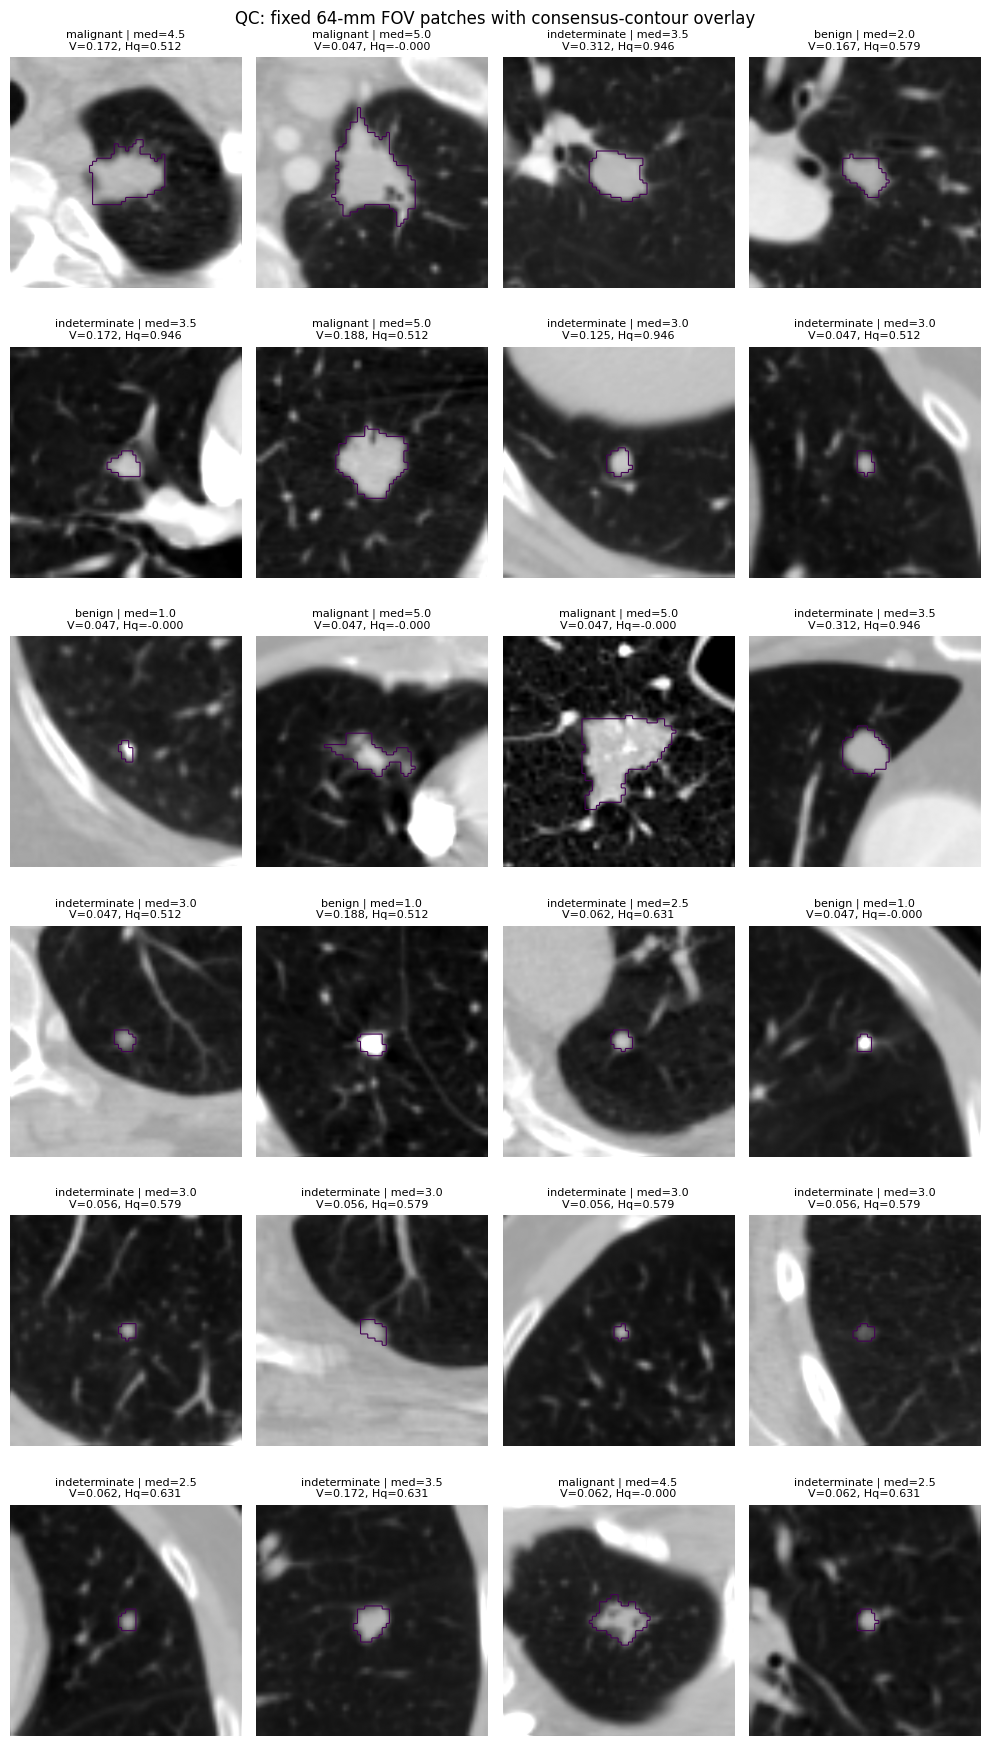

In [19]:
for class_name in ['benign','indeterminate','malignant']:
    subset=final_df[final_df['label_name']==class_name].head(15)
    out_dir=PATHS['preview_labels']/class_name; out_dir.mkdir(parents=True,exist_ok=True)
    for _,r in subset.iterrows(): save_preview_png(np.load(r['patch_path']),out_dir/f"{r['nodule_id']}.png")

sample=final_df.sample(min(24,len(final_df)),random_state=SEED).reset_index(drop=True)
fig,axes=plt.subplots(6,4,figsize=(10,18)); axes=np.asarray(axes).reshape(-1)
for ax in axes: ax.axis('off')
for ax,(_,r) in zip(axes,sample.iterrows()):
    img=np.load(r['patch_path']); mask=np.load(r['consensus_mask_path'])
    ax.imshow(img,cmap='gray',vmin=0,vmax=1)
    ax.contour(mask,levels=[0.5],linewidths=0.8)
    ax.set_title(f"{r['label_name']} | med={r['malignancy_median']}\nV={r['variance_normalized']:.3f}, Hq={r['reader_vote_entropy_normalized']:.3f}",fontsize=8)
    ax.axis('off')
fig.suptitle('QC: fixed 64-mm FOV patches with consensus-contour overlay'); fig.tight_layout()
fig.savefig(PATHS['preview_qc']/'qc_contact_sheet_with_masks.png',dpi=150,bbox_inches='tight'); plt.show()


## 19. Final integrity checks, independent recomputation, and EDA


{
  "patients_local": 30,
  "valid_scans": 30,
  "raw_nodule_clusters": 86,
  "eligible_nodules_before_patch_failures": 48,
  "final_patches": 48,
  "zero_variance_nodules": 0,
  "alignment_enabled_nodules": 48,
  "unique_patients_final": 21,
  "class_counts": {
    "indeterminate": 33,
    "malignant": 10,
    "benign": 5
  },
  "sensitivity_class_counts": {
    "indeterminate": 24,
    "malignant": 19,
    "benign": 5
  },
  "patch_shape_correct": true,
  "mask_shape_correct": true,
  "patch_range_0_1": true,
  "labels_valid": true,
  "variance_range_0_1": true,
  "reader_vote_rows_sum_to_1": true,
  "minimum_radiologists_respected": true,
  "minimum_diameter_respected": true,
  "patient_in_single_fold": true,
  "all_five_folds_present": true,
  "physical_fov_mm_unique": [
    64.0
  ],
  "target_spacing_mm_unique": [
    1.0
  ]
}


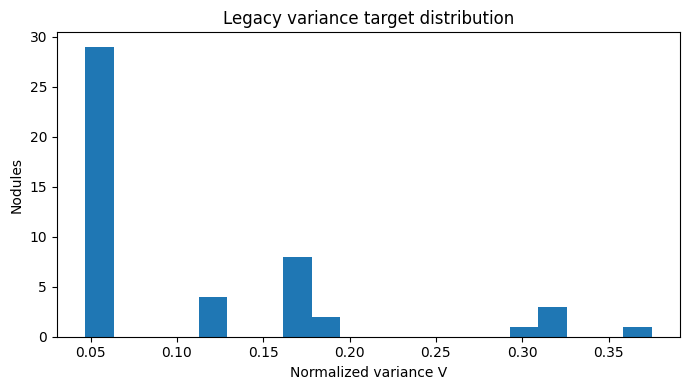

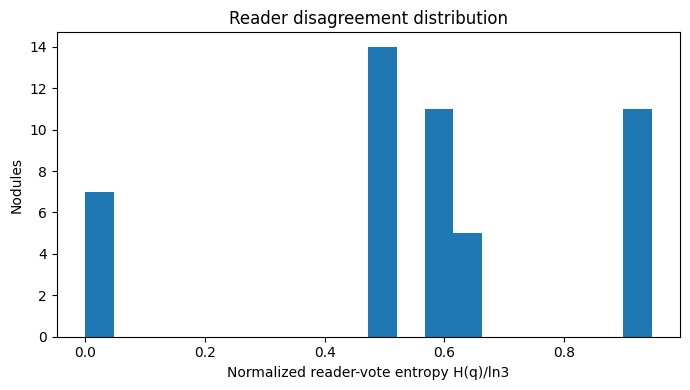

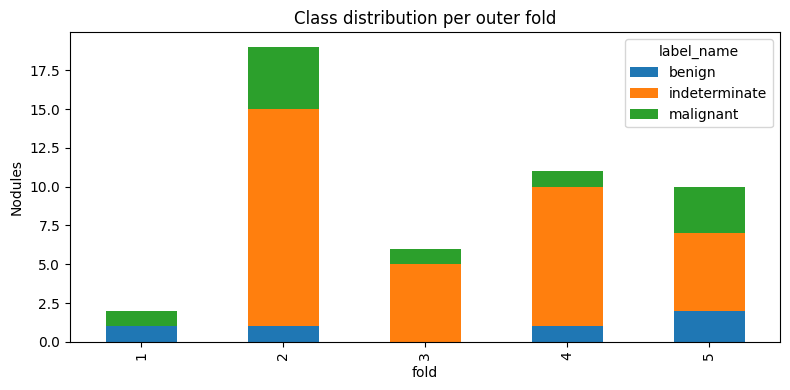

In [20]:
# V7/data-contract assertions: recompute labels, V and reader-vote q independently from stored reader scores.
def parse_scores(s): return np.array([float(x) for x in str(s).split('|') if str(x).strip()!=''],dtype=float)
for _,r in final_df.iterrows():
    scores=parse_scores(r['malignancy_scores'])
    m=float(np.median(scores)); _,lid=label_from_median(m)
    v=float(np.var(scores,ddof=0)); V=float(np.clip(v/4.0,0,1)); q,h=reader_vote_distribution(scores)
    assert lid==int(r['label_id'])
    assert np.isclose(V,float(r['variance_normalized']),atol=1e-8)
    assert np.allclose(q,[r['q_benign'],r['q_indeterminate'],r['q_malignant']],atol=1e-8)
    assert np.isclose(h,float(r['reader_vote_entropy_normalized']),atol=1e-8)

validation={
    'patients_local':int(dicom_inventory.patient_id.nunique()), 'valid_scans':int(len(VALID_SCANS)),
    'raw_nodule_clusters':int(len(nodule_raw_df)), 'eligible_nodules_before_patch_failures':int(len(nodule_df)),
    'final_patches':int(len(final_df)), 'zero_variance_nodules':int((final_df.variance_normalized==0).sum()),
    'alignment_enabled_nodules':int((final_df.alignment_mask==1).sum()), 'unique_patients_final':int(final_df.patient_id.nunique()),
    'class_counts':{k:int(v) for k,v in final_df.label_name.value_counts().to_dict().items()},
    'sensitivity_class_counts':{k:int(v) for k,v in final_df.label_name_sensitivity.value_counts().to_dict().items()},
    'patch_shape_correct':bool(images.ndim==3 and images.shape[1:]==(224,224)),
    'mask_shape_correct':bool(consensus_masks.shape==images.shape),
    'patch_range_0_1':bool(np.nanmin(images)>=0 and np.nanmax(images)<=1),
    'labels_valid':bool(set(np.unique(labels)).issubset({0,1,2})),
    'variance_range_0_1':bool(np.nanmin(variance_targets)>=0 and np.nanmax(variance_targets)<=1),
    'reader_vote_rows_sum_to_1':bool(np.allclose(reader_vote_targets.sum(axis=1),1.0)),
    'minimum_radiologists_respected':bool((final_df.n_radiologists>=3).all()),
    'minimum_diameter_respected':bool((final_df.diameter_mm>=3).all()),
    'patient_in_single_fold':bool((final_df.groupby('patient_id')['fold'].nunique()==1).all()),
    'all_five_folds_present':bool(set(final_df.fold.unique())=={1,2,3,4,5}),
    'physical_fov_mm_unique':sorted(final_df.field_of_view_mm.unique().tolist()),
    'target_spacing_mm_unique':sorted(final_df.target_pixel_spacing_mm.unique().tolist()),
}
if not all([validation['patch_shape_correct'],validation['mask_shape_correct'],validation['patch_range_0_1'],
            validation['labels_valid'],validation['variance_range_0_1'],validation['reader_vote_rows_sum_to_1'],
            validation['minimum_radiologists_respected'],validation['minimum_diameter_respected'],
            validation['patient_in_single_fold'],validation['all_five_folds_present']]):
    raise AssertionError('One or more final preprocessing integrity checks failed.')
print(json.dumps(validation,indent=2))

plt.figure(figsize=(7,4)); plt.hist(final_df['variance_normalized'],bins=20); plt.xlabel('Normalized variance V'); plt.ylabel('Nodules'); plt.title('Legacy variance target distribution'); plt.tight_layout(); plt.savefig(PATHS['preview_qc']/'variance_histogram.png',dpi=150); plt.show()
plt.figure(figsize=(7,4)); plt.hist(final_df['reader_vote_entropy_normalized'],bins=20); plt.xlabel('Normalized reader-vote entropy H(q)/ln3'); plt.ylabel('Nodules'); plt.title('Reader disagreement distribution'); plt.tight_layout(); plt.savefig(PATHS['preview_qc']/'reader_vote_entropy_histogram.png',dpi=150); plt.show()
per_fold=final_df.groupby(['fold','label_name']).size().unstack(fill_value=0).reindex(columns=['benign','indeterminate','malignant'],fill_value=0)
ax=per_fold.plot(kind='bar',stacked=True,figsize=(8,4)); ax.set_ylabel('Nodules'); ax.set_title('Class distribution per outer fold'); plt.tight_layout(); plt.savefig(PATHS['preview_qc']/'class_distribution_per_fold.png',dpi=150); plt.show()


## 20. Dataset summary, shared run configuration, and logs


In [21]:
dataset_summary={
    'created_at':datetime.now().isoformat(timespec='seconds'), 'dataset':'LIDC-IDRI',
    'preprocessing_version':CONFIG['preprocessing_version'],
    'PILOT_MAX_PATIENTS':PILOT_MAX_PATIENTS, 'pilot_max_patients':PILOT_MAX_PATIENTS,
    'pilot':bool(PILOT_MAX_PATIENTS is not None),
    'source_patient_count_detected':int(dicom_inventory.patient_id.nunique()), 'valid_scan_count':int(len(VALID_SCANS)),
    'final_patient_count':int(final_df.patient_id.nunique()), 'final_nodule_count':int(len(final_df)),
    'class_mapping':CLASS_MAPPING, 'class_counts':validation['class_counts'],
    'sensitivity_class_counts':validation['sensitivity_class_counts'],
    'hard_label_policy':CONFIG['labels']['primary_rule'], 'hard_label_sensitivity_policy':CONFIG['labels']['sensitivity_rule'],
    'reader_vote_mapping':CONFIG['labels']['reader_vote_mapping'],
    'stored_patch_shape':[224,224,1], 'pretrained_backbone_runtime_shape':[224,224,3],
    'crop_geometry':CONFIG['crop_geometry'], 'hu_window':[HU_LOW,HU_HIGH],
    'variance_target':'population variance / 4.0 (legacy scalar disagreement target)',
    'reader_disagreement_target':'ternary reader vote distribution q plus H(q)/ln(3)',
    'zero_variance_handling':'classification=yes; legacy scalar alignment_mask=0',
    'cross_validation':'single 5-fold patient-level StratifiedGroupKFold, seed 42',
    'fold_assignments_sha256':fold_sha256, 'seed':SEED, 'validation':validation,
}
with open(PATHS['metadata']/'dataset_summary.json','w') as f: json.dump(dataset_summary,f,indent=2)

# Refresh compatibility run-config files with the actual fold hash.
shared_run_config.update({'fold_assignments_sha256':fold_sha256,'final_patient_count':int(final_df.patient_id.nunique()),
                          'final_nodule_count':int(len(final_df))})
for name in ['shared_pipeline_config.json','preprocessing_run_config.json']:
    (PATHS['metadata']/name).write_text(json.dumps(shared_run_config,indent=2))

log_event('finalize','OK',f'Final dataset contains {len(final_df)} nodules; fold_sha256={fold_sha256}')
flush_logs(); print(json.dumps(dataset_summary,indent=2))


{
  "created_at": "2026-10-05T09:57:16",
  "dataset": "LIDC-IDRI",
  "preprocessing_version": "3.2-corrected",
  "PILOT_MAX_PATIENTS": null,
  "pilot_max_patients": null,
  "pilot": false,
  "source_patient_count_detected": 30,
  "valid_scan_count": 30,
  "final_patient_count": 21,
  "final_nodule_count": 48,
  "class_mapping": {
    "benign": 0,
    "indeterminate": 1,
    "malignant": 2
  },
  "class_counts": {
    "indeterminate": 33,
    "malignant": 10,
    "benign": 5
  },
  "sensitivity_class_counts": {
    "indeterminate": 24,
    "malignant": 19,
    "benign": 5
  },
  "hard_label_policy": "median <=2 benign; 2.5-3.5 indeterminate; >=4 malignant",
  "hard_label_sensitivity_policy": "median <2.5 benign; 2.5<=median<3.5 indeterminate; >=3.5 malignant",
  "reader_vote_mapping": "reader score 1-2 benign; 3 indeterminate; 4-5 malignant",
  "stored_patch_shape": [
    224,
    224,
    1
  ],
  "pretrained_backbone_runtime_shape": [
    224,
    224,
    3
  ],
  "crop_geometry": {


## 21. Write reusable helper scripts into `preprocessing/scripts/`

In [22]:
scripts = {
'extract_xml.py': '''from pathlib import Path
import zipfile
def extract_xml(zip_path, output_dir):
    output_dir=Path(output_dir); output_dir.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(zip_path,'r') as zf: zf.extractall(output_dir)
    return sorted(output_dir.rglob('*.xml'))
''',
'parse_annotations.py': '''import numpy as np
def ternary_label_from_scores(scores):
    m=float(np.median(np.asarray(scores,dtype=float)))
    return ('benign',0) if m<=2 else (('indeterminate',1) if m<=3.5 else ('malignant',2))
def reader_vote_distribution(scores):
    cls=[0 if s<=2 else (1 if s==3 else 2) for s in np.asarray(scores,dtype=float)]
    q=np.bincount(cls,minlength=3).astype(float); q/=q.sum(); return q
def disagreement_target(scores):
    v=float(np.var(np.asarray(scores,dtype=float),ddof=0)); V=float(np.clip(v/4.0,0,1)); return v,V,int(V>0)
''',
'extract_dicom.py': '''import pydicom
def read_dicom_header(path): return pydicom.dcmread(str(path),stop_before_pixels=True,force=True)
''',
'generate_patches.py': '''import numpy as np
def lung_window(patch,lo=-1000.,hi=400.):
    patch=np.clip(np.asarray(patch,dtype=np.float32),lo,hi); return ((patch-lo)/(hi-lo)).astype(np.float32)
''',
'validate_dataset.py': '''def assert_no_patient_leakage(df):
    assert (df.groupby('patient_id')['fold'].nunique()==1).all(); return True
'''
}
for filename,content in scripts.items():
    (PATHS['scripts']/filename).write_text(content)
print('Scripts written:',sorted(scripts))


Scripts written: ['extract_dicom.py', 'extract_xml.py', 'generate_patches.py', 'parse_annotations.py', 'validate_dataset.py']


## 22. Write `LIDC/README.md`

In [23]:
readme = f"""# LIDC-IDRI Thesis Data Pipeline — preprocessing {CONFIG['preprocessing_version']}

Authoritative preprocessing protocol:
- diameter >= 3 mm; >= 3 radiologist annotations
- primary hard label: median <=2 benign; 2.5-3.5 indeterminate; >=4 malignant
- sensitivity hard label: median <2.5 benign; 2.5<=median<3.5 indeterminate; >=3.5 malignant
- reader vote q: scores 1-2 benign, 3 indeterminate, 4-5 malignant
- legacy V = population variance / 4.0; zero-V remains in classification and has alignment_mask=0
- largest consensus-contour axial slice
- resample in-plane to {TARGET_SPACING_MM:g} mm/pixel, crop fixed {FOV_MM:g} mm FOV, resize to 224x224
- HU [-1000,400] -> [0,1]
- single patient-level StratifiedGroupKFold 5-fold assignment, seed 42
- fold SHA-256: {fold_sha256}
- PILOT_MAX_PATIENTS: {PILOT_MAX_PATIENTS}

All B1/B2/B3/B4/C1 notebooks must read labels/folds from these artifacts; folder names are never label sources.
"""
(LIDC_ROOT/'README.md').write_text(readme)
print('README written:',LIDC_ROOT/'README.md')


README written: /content/drive/MyDrive/Thesis_Work/LIDC_Thesis/LIDC/README.md


## 23. Final output checklist

In [24]:
required_outputs=[
    PATHS['annotation_inventory'], PATHS['configs']/'preprocessing_config.yaml', PATHS['configs']/'class_mapping.json',
    PATHS['logs']/'preprocessing_log.csv', PATHS['logs']/'failed_patients.csv', PATHS['logs']/'excluded_nodules.csv',
    PATHS['metadata']/'lidc_patches_metadata.csv', PATHS['metadata']/'detailed_nodule_metadata.csv',
    PATHS['metadata']/'patient_inventory.csv', PATHS['metadata']/'annotation_inventory.csv',
    PATHS['metadata']/'dataset_summary.json', PATHS['metadata']/'fold_assignments.csv', PATHS['metadata']/'fold_assignments.sha256',
    PATHS['metadata']/'shared_pipeline_config.json', PATHS['metadata']/'preprocessing_run_config.json',
    PATHS['arrays']/'images.npy', PATHS['arrays']/'consensus_masks.npy', PATHS['arrays']/'labels.npy',
    PATHS['arrays']/'variance_targets.npy', PATHS['arrays']/'alignment_masks.npy', PATHS['arrays']/'patient_ids.npy',
    PATHS['arrays']/'reader_vote_targets.npy', LIDC_ROOT/'README.md'
]
status=pd.DataFrame({'artifact':[str(p) for p in required_outputs],'exists':[p.exists() for p in required_outputs]})
display(status)
if not bool(status.exists.all()):
    missing=status.loc[~status.exists,'artifact'].tolist(); raise RuntimeError(f'Missing required outputs: {missing}')
print('All required outputs exist: True')
print('Shared fold SHA-256:',fold_sha256)
print('Next: B1, B2, B3, B4 and C1 must consume this exact metadata/fold contract.')


,artifact,exists
0,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
1,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
2,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
3,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
4,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
5,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
6,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
7,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
8,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True
9,/content/drive/MyDrive/Thesis_Work/LIDC_Thesis...,True


All required outputs exist: True
Shared fold SHA-256: 6579bbae4001911dbeb74213340e7846c3dcc2d03f915ed501c0ec339446a060
Next: B1, B2, B3, B4 and C1 must consume this exact metadata/fold contract.
